In [17]:
# Imports
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor
import torch.nn.functional as F

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

from joblib import Parallel, delayed
from tqdm.auto import tqdm

import numpy as np

import matplotlib.pyplot as plt

import copy
import time


 ## **Task 1**

 Look into the MNist data set. Explore the effects of patch size on wrapper method feature selection methods (LOCO, MinShap, Etc.)



In [3]:
# Load
train = datasets.MNIST(root='.', train=True, download=True)
test  = datasets.MNIST(root='.', train=False, download=True)

X_train = train.data.numpy().reshape(60000, -1) / 255.0  # (60000, 784)
y_train = train.targets.numpy()                           # (60000,)

X_test  = test.data.numpy().reshape(10000, -1) / 255.0   # (10000, 784)
y_test  = test.targets.numpy()                            # (10000,)

100%|███████████████████████████████████████| 9.91M/9.91M [00:27<00:00, 362kB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 275kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 1.70MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.29MB/s]


In [4]:
# Take a smaller sample
X_train = X_train[:30_000]
y_train = y_train[:30_000]
X_test = X_test[:3_000]
y_test = y_test[:3_000]

### LOCO

#### Logistic Regression

In [21]:
clf_full=LogisticRegression(solver='lbfgs', max_iter=300)
clf_full.fit(X_train,y_train)
full_acc = accuracy_score(y_test, clf_full.predict(X_test))
full_acc

0.9013333333333333

In [23]:
def loco_one_feature(j):
    X_train_j = X_train.copy()
    X_test_j  = X_test.copy()
    X_train_j[:, j] = 0
    X_test_j[:, j]  = 0

    clf_j = LogisticRegression(solver='lbfgs', max_iter=300, warm_start=True)
    clf_j.fit(X_train_j, y_train)
    j_acc = accuracy_score(y_test, clf_j.predict(X_test_j))
    return j_acc - full_acc  # importance = how much worse

results = Parallel(n_jobs=-1, return_as="generator")(
    delayed(loco_one_feature)(j) for j in range(784)
)

importances = list(tqdm(results, total=784, desc="LOCO refits"))

LOCO refits: 100%|████████████████████████████| 784/784 [42:07<00:00,  3.22s/it]


In [36]:
def get_patches(patch_size, img_size=28):
    """Returns list of patch index arrays for flattened 784-dim vector."""
    patches = []
    for i in range(0, img_size, patch_size):
        for j in range(0, img_size, patch_size):
            idx = [
                (i + di) * img_size + (j + dj)
                for di in range(patch_size)
                for dj in range(patch_size)
            ]
            patches.append(np.array(idx))
    return patches

In [38]:
def plot_importance(importances, patch_size, img_size=28):
    """Map patch importances back to pixel grid and plot."""
    patches = get_patches(patch_size, img_size)
    pixel_importance = np.zeros(img_size * img_size)
    
    for patch_idx, patch in enumerate(patches):
        pixel_importance[patch] = importances[patch_idx]
    
    plt.figure(figsize=(5, 4))
    plt.imshow(pixel_importance.reshape(img_size, img_size), cmap='hot')
    plt.colorbar(label='LOCO importance')
    plt.title(f'Patch size {patch_size}×{patch_size} ({len(patches)} patches)')
    plt.axis('off')
    plt.show()

In [78]:
def loco_one_patch(patch_indices):
    X_train_j = X_train.copy()
    X_test_j  = X_test.copy()
    X_train_j[:, patch_indices] = 0
    X_test_j[:, patch_indices]  = 0
    clf_j = LogisticRegression(solver='lbfgs', max_iter=300, warm_start=True)
    clf_j.coef_ = clf_full.coef_.copy()
    clf_j.intercept_ = clf_full.intercept_.copy()
    clf_j.classes_ = clf_full.classes_
    clf_j.fit(X_train_j, y_train)

    return accuracy_score(y_test, clf_j.predict(X_test_j)) - full_acc
def run_loco(patch_size):
    patches = get_patches(patch_size)
    results = Parallel(n_jobs=-1)(
        delayed(loco_one_patch)(patch) for patch in tqdm(patches, desc=f"{patch_size}x{patch_size}",  total=len(patches))
    )
    return np.array(results)

In [83]:
logit_importances = importances

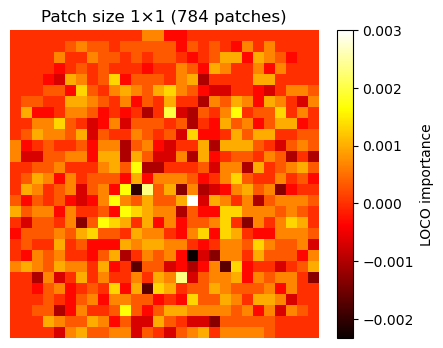

In [84]:
plot_importance(logit_importances, patch_size=1)

In [82]:
logit_2_patch_importances = run_loco(2)









2x2:   0%|                                              | 0/196 [00:00<?, ?it/s]







2x2:   8%|███                                  | 16/196 [00:00<00:10, 16.48it/s]







2x2:  12%|████▌                                | 24/196 [00:01<00:08, 21.22it/s]







2x2:  16%|██████                               | 32/196 [00:01<00:08, 20.45it/s]







2x2:  20%|███████▌                             | 40/196 [00:03<00:17,  8.72it/s]







2x2:  24%|█████████                            | 48/196 [00:07<00:34,  4.34it/s]







2x2:  29%|██████████▌                          | 56/196 [00:08<00:27,  5.05it/s]







2x2:  33%|████████████                         | 64/196 [00:12<00:42,  3.14it/s]







2x2:  37%|█████████████▌                       | 72/196 [00:16<00:43,  2.82it/s]







2x2:  41%|███████████████                      | 80/196 [00:19<00:43,  2.65it/s]







2x2:  45%|████████████████▌                    | 88/196 [00:23<00:45,  2.40it/s]







2x2:  49%|██████████████

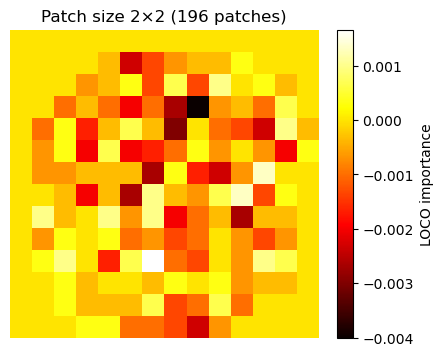

In [90]:
plot_importance(logit_2_patch_importances, patch_size=2)









4x4:   0%|                                               | 0/49 [00:00<?, ?it/s]







4x4:  33%|████████████▍                         | 16/49 [00:00<00:01, 19.13it/s]







4x4:  49%|██████████████████▌                   | 24/49 [00:06<00:08,  2.98it/s]







4x4:  65%|████████████████████████▊             | 32/49 [00:12<00:08,  2.08it/s]







4x4:  82%|███████████████████████████████       | 40/49 [00:23<00:06,  1.29it/s]







4x4: 100%|██████████████████████████████████████| 49/49 [00:32<00:00,  1.50it/s]


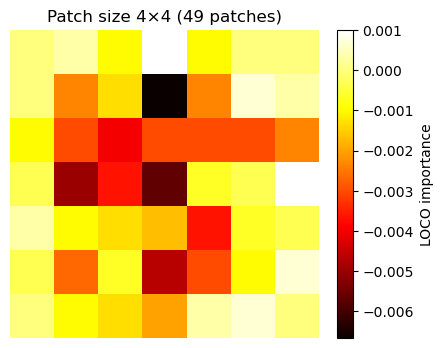

In [92]:
logit_4_patch_importances = run_loco(4)
plot_importance(logit_4_patch_importances, patch_size=4)









7x7:   0%|                                               | 0/16 [00:00<?, ?it/s]







7x7: 100%|██████████████████████████████████████| 16/16 [00:03<00:00,  4.54it/s]


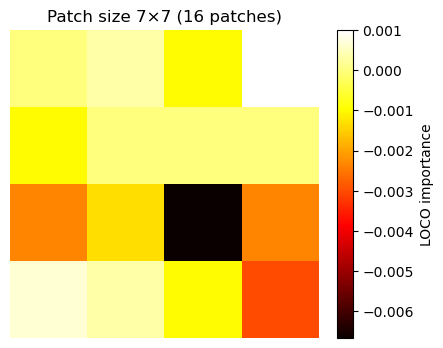

In [96]:
logit_7_patch_importances = run_loco(7)
plot_importance(logit_4_patch_importances, patch_size=7)

#### Neural Networks

In [139]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )
 
    def forward(self, x):
        return self.net(x)
 
 
def get_loader(train=False):
    ds = datasets.MNIST("./data", train=train, download=True, transform=transforms.ToTensor())
    return DataLoader(ds, batch_size=256, shuffle=train)
 
 
def train(epochs=3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SimpleCNN().to(device)
    opt = torch.optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for X, y in get_loader(train=True):
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss_fn(model(X), y).backward()
            opt.step()
        print(f"Epoch {epoch+1}/{epochs} done")
    return model
 
 
def eval_loss(model, mask_fn=None):
    device = next(model.parameters()).device
    loss_fn = nn.CrossEntropyLoss()
    total = 0.0
    model.eval()
    with torch.no_grad():
        for X, y in get_loader():
            X, y = X.to(device), y.to(device)
            if mask_fn:
                X = mask_fn(X)
            total += loss_fn(model(X), y).item() * len(y)
    return total / 10000
 
 
def run_loco(model, patch_size=7):
    assert 28 % patch_size == 0
    baseline = eval_loss(model)
    n = 28 // patch_size
    importance = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r0, r1 = i * patch_size, (i + 1) * patch_size
            c0, c1 = j * patch_size, (j + 1) * patch_size
            def mask(X, r0=r0, r1=r1, c0=c0, c1=c1):
                X = X.clone(); X[:, :, r0:r1, c0:c1] = 0; return X
            importance[i, j] = eval_loss(model, mask) - baseline
    return importance, baseline
 
 
def plot_loco(importance, patch_size=7):
    plt.imshow(importance, cmap="hot")
    plt.colorbar(label="Δ loss")
    plt.title(f"LOCO importance ({patch_size}×{patch_size} patches)")
    plt.xlabel("patch col"); plt.ylabel("patch row")
    plt.tight_layout()
    plt.show()

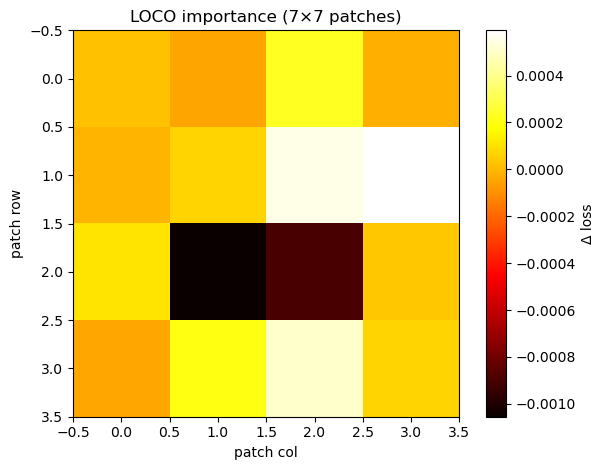

In [147]:
n = 7
nn_importances_1, baseline = run_loco(SimpleCNN(), patch_size=n)
plot_loco(nn_importances_1, patch_size=n)

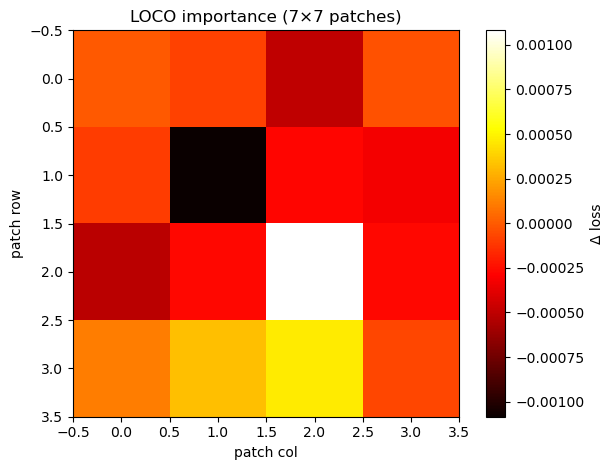

In [145]:
n = 7
nn_importances_1, baseline = run_loco(SimpleCNN(), patch_size=n)
plot_loco(nn_importances_1, patch_size=n)

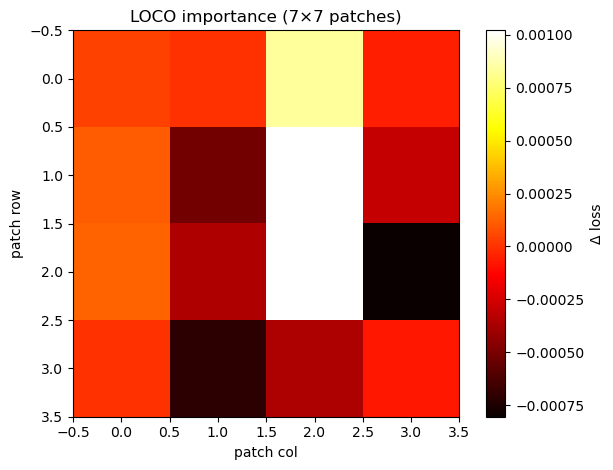

In [149]:
n = 7
nn_importances_1, baseline = run_loco(SimpleCNN(), patch_size=n)
plot_loco(nn_importances_1, patch_size=n)

### MinShap

In [167]:
def eval_losses(model, loader, included, patch_size):
    """Per-sample CE losses with all patches outside `included` zeroed."""
    device = next(model.parameters()).device
    mask = torch.zeros(1, 1, 28, 28, device=device)
    for i, j in included:
        mask[:, :, i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = 1.0
 
    loss_fn = nn.CrossEntropyLoss(reduction="none")
    model.eval()
    with torch.no_grad():
        losses = [loss_fn(model(X.to(device) * mask), y.to(device)).cpu().numpy()
                  for X, y in loader]
    return np.concatenate(losses)
 
 
def minshap(model, loader, patch_size=7, K=50, alpha=0.05, seed=42):
    assert 28 % patch_size == 0
    g = 28 // patch_size
    patches = [(i, j) for i in range(g) for j in range(g)]
    p = len(patches)
    rng = np.random.default_rng(seed)
 
    VI   = np.zeros((K, p))
    sig2 = np.zeros((K, p))
 
    e_cur = eval_losses(model, loader, [], patch_size)  # null model residuals
 
    t0 = time.time()
    for k in range(K):
        pi    = rng.permutation(p)
        e_cur = eval_losses(model, loader, [], patch_size).copy()
        V_cur = -e_cur.mean()
 
        for i, j in enumerate(pi):
            e_new = eval_losses(model, loader, [patches[pi[t]] for t in range(i+1)], patch_size)
            V_new = -e_new.mean()
            VI[k, j]   = V_cur - V_new
            sig2[k, j] = np.var(e_cur - e_new) / len(e_cur)
            V_cur, e_cur = V_new, e_new
 
        print(f"[{k+1}/{K}] {time.time()-t0:.1f}s", flush=True)
 
    phi_min  = VI.min(axis=0)
    t_thresh = np.sqrt(-2 * np.log(alpha) * sig2[0])
    selected = (phi_min >= t_thresh).reshape(g, g)
 
    return phi_min.reshape(g, g), t_thresh.reshape(g, g), selected
 
 
def plot_minshap(phi_min, t_thresh, selected, patch_size, alpha=0.05):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
 
    vmax = np.abs(phi_min).max()
    axes[0].imshow(phi_min, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[0].set_title("phi_min")
 
    axes[1].imshow(t_thresh, cmap="viridis")
    axes[1].set_title("threshold t_j")
 
    axes[2].imshow(selected, cmap="Greens", vmin=0, vmax=1)
    axes[2].set_title(f"selected (alpha={alpha})")
    for i in range(selected.shape[0]):
        for j in range(selected.shape[1]):
            axes[2].text(j, i, "✓" if selected[i, j] else "✗",
                         ha="center", va="center", fontsize=11,
                         color="white" if selected[i, j] else "#aaa")
 
    plt.suptitle(f"{patch_size}x{patch_size} patches")
    plt.tight_layout()
    plt.show()

In [169]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 28, 28)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256)

minshap_7 = minshap(SimpleCNN(), loader, patch_size=7, K=50)
plot_minshap(minshap_7, 7)

[1/50] 1.6s
[2/50] 3.3s
[3/50] 5.1s
[4/50] 6.6s
[5/50] 8.3s
[6/50] 9.8s
[7/50] 11.6s
[8/50] 13.1s
[9/50] 14.8s
[10/50] 16.4s
[11/50] 18.0s
[12/50] 19.6s
[13/50] 21.3s
[14/50] 23.1s
[15/50] 24.7s
[16/50] 26.4s
[17/50] 28.1s
[18/50] 29.8s
[19/50] 31.6s
[20/50] 33.3s
[21/50] 35.2s
[22/50] 36.9s
[23/50] 38.7s
[24/50] 40.3s
[25/50] 42.3s
[26/50] 44.0s
[27/50] 45.6s
[28/50] 47.3s
[29/50] 48.9s
[30/50] 50.5s
[31/50] 52.1s
[32/50] 53.8s
[33/50] 55.5s
[34/50] 57.1s
[35/50] 58.7s
[36/50] 60.3s
[37/50] 61.9s
[38/50] 63.5s
[39/50] 65.2s
[40/50] 67.0s
[41/50] 68.7s
[42/50] 70.4s
[43/50] 72.2s
[44/50] 73.9s
[45/50] 75.5s
[46/50] 77.2s
[47/50] 78.8s
[48/50] 80.5s
[49/50] 82.2s
[50/50] 84.0s


TypeError: plot_minshap() missing 2 required positional arguments: 'selected' and 'patch_size'

In [ ]:
minshap_7 = minshap(SimpleCNN(), loader, patch_size=7, K=50)
plot_minshap(minshap_7, 7)

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- patches ----
def get_patches(patch_size, img_size=28):
    patches = []
    for i in range(0, img_size, patch_size):
        for j in range(0, img_size, patch_size):
            idx = [(i+di)*img_size + (j+dj) for di in range(patch_size) for dj in range(patch_size)]
            patches.append(np.array(idx))
    return patches

def _cols(patches, S):
    return np.concatenate([patches[j] for j in S]) if len(S) else np.array([], dtype=int)

# ---- base learner ----
class MLP(nn.Module):
    def __init__(self, d_in, n_classes=10, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(),
                                 nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)

def _fit_loss(Xtr, ytr, Xte, yte, cols, n_classes=10, hidden=64,
              epochs=10, batch=256, lr=1e-3, wd=1e-4, seed=0):
    yte_t = torch.as_tensor(yte, dtype=torch.long, device=DEVICE)
    if len(cols) == 0:                                    # null: class prior
        prior = np.bincount(ytr, minlength=n_classes) / len(ytr)
        p = np.clip(prior[yte], 1e-12, 1.0)
        return torch.as_tensor(-np.log(p), dtype=torch.float32, device=DEVICE)
    torch.manual_seed(seed)
    Xtr_t = torch.as_tensor(Xtr[:, cols], dtype=torch.float32, device=DEVICE)
    ytr_t = torch.as_tensor(ytr,          dtype=torch.long,    device=DEVICE)
    Xte_t = torch.as_tensor(Xte[:, cols], dtype=torch.float32, device=DEVICE)
    model = MLP(len(cols), n_classes, hidden).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    n = len(ytr_t)
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            F.cross_entropy(model(Xtr_t[idx]), ytr_t[idx]).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        return F.cross_entropy(model(Xte_t), yte_t, reduction="none")

def minshap(Xtr, ytr, Xte, yte, patches, K=30, alpha=0.05, u=1,
            n_classes=10, epochs=10, train_subsample=5000, seed=0):
    rng = np.random.default_rng(seed)
    if train_subsample and train_subsample < len(ytr):
        idx = rng.choice(len(ytr), train_subsample, replace=False)
        Xtr, ytr = Xtr[idx], ytr[idx]
    p, n_te = len(patches), len(yte)
    VI   = np.zeros((K, p))
    sig2 = np.zeros((K, p))

    pbar = tqdm(range(K), desc="MinShap perms", leave=False)
    for k in pbar:
        pi = rng.permutation(p)
        loss_prev = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, []),
                              n_classes=n_classes, epochs=epochs)
        V_prev = -loss_prev.mean().item()
        S = []
        inner = tqdm(pi, desc=f"  perm {k+1}/{K}", leave=False)
        for j in inner:
            j = int(j); S_new = S + [j]
            loss_new = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, S_new),
                                 n_classes=n_classes, epochs=epochs,
                                 seed=seed + k*10000 + len(S))
            V_new = -loss_new.mean().item()
            VI[k, j]   = V_new - V_prev
            diff       = (loss_prev - loss_new).detach().cpu().numpy()
            sig2[k, j] = diff.var(ddof=1) / n_te
            S, loss_prev, V_prev = S_new, loss_new, V_new
            inner.set_postfix(V=f"{V_new:.3f}", dV=f"{V_new-V_prev:+.4f}")
        # running summary: how many patches have nonzero phi_min so far?
        VI_so_far = np.maximum(VI[:k+1], 0.0).min(axis=0)
        pbar.set_postfix(nonzero=f"{(VI_so_far > 0).sum()}/{p}")

    VI_c   = np.maximum(VI, 0.0)
    order  = np.argsort(VI_c, axis=0)
    u_row  = order[u-1]
    cols_a = np.arange(p)
    phi    = VI_c[u_row, cols_a]
    sig2_u = sig2[u_row, cols_a]
    sig2_eff = np.where(sig2_u > 1e-12, sig2_u, sig2.max(axis=0))
    thresh = np.sqrt(np.maximum(-2*np.log(alpha)*sig2_eff, 0.0))
    return phi, thresh, phi > thresh, VI

# ---- add tqdm to loco ----
def loco(Xtr, ytr, Xte, yte, patches, alpha=0.05, n_classes=10,
         epochs=10, train_subsample=5000, seed=0):
    rng = np.random.default_rng(seed)
    if train_subsample and train_subsample < len(ytr):
        idx = rng.choice(len(ytr), train_subsample, replace=False)
        Xtr, ytr = Xtr[idx], ytr[idx]
    p = len(patches); all_idx = list(range(p))
    loss_full = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, all_idx),
                          n_classes=n_classes, epochs=epochs, seed=seed)
    V_full = -loss_full.mean().item()
    pvals = np.zeros(p); scores = np.zeros(p)
    bar = tqdm(range(p), desc=f"LOCO (V_full={V_full:.3f})", leave=False)
    for j in bar:
        S_mj = all_idx[:j] + all_idx[j+1:]
        loss_mj = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, S_mj),
                            n_classes=n_classes, epochs=epochs, seed=seed+j+1)
        diff = (loss_mj - loss_full).detach().cpu().numpy()
        scores[j] = diff.mean()
        pvals[j]  = ttest_1samp(diff, 0.0, alternative="greater").pvalue
        bar.set_postfix(rejected=f"{(pvals[:j+1] < alpha).sum()}/{j+1}")
    return scores, pvals, pvals < alpha

In [19]:
# ---- experiment with outer progress + richer summaries ----
Xtr = X_train.astype(np.float32); ytr = y_train.astype(np.int64)
Xte = X_test.astype(np.float32);  yte = y_test.astype(np.int64)

results = {}
outer = tqdm([2, 4, 7], desc="patch sizes")
for s in outer:
    patches = get_patches(s); p = len(patches)
    outer.write(f"\n=== patch={s}x{s}  p={p} ===")

    t0 = time.time()
    phi, thr, rej_ms, VI = minshap(Xtr, ytr, Xte, yte, patches,
                                    K=30, alpha=0.05, u=1,
                                    epochs=10, train_subsample=5000)
    dt_ms = time.time() - t0
    outer.write(f"MinShap: {dt_ms:.0f}s  selected {rej_ms.sum()}/{p}  "
                f"indices={np.where(rej_ms)[0].tolist()}")
    outer.write(f"  phi range [{phi.min():.4f}, {phi.max():.4f}]  "
                f"thr range [{thr.min():.4f}, {thr.max():.4f}]")

    t0 = time.time()
    scores, pvals, rej_lo = loco(Xtr, ytr, Xte, yte, patches, alpha=0.05,
                                  epochs=10, train_subsample=5000)
    dt_lo = time.time() - t0
    outer.write(f"LOCO:    {dt_lo:.0f}s  selected {rej_lo.sum()}/{p}  "
                f"indices={np.where(rej_lo)[0].tolist()}")

    overlap = set(np.where(rej_ms)[0]) & set(np.where(rej_lo)[0])
    outer.write(f"  agreement: {len(overlap)} patches selected by both")

    results[s] = dict(phi=phi, thresh=thr, VI=VI,
                      ms_rejected=rej_ms, loco_rejected=rej_lo,
                      loco_scores=scores, loco_pvals=pvals)

patch sizes:   0%|          | 0/3 [00:00<?, ?it/s]


=== patch=2x2  p=196 ===


MinShap perms:   0%|          | 0/30 [00:00<?, ?it/s]

  perm 1/30:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [69]:
from tqdm import tqdm

def run_minshap(patch_size, X_train, y_train, X_test, y_test,
                K=30, alpha=0.05, u=1, epochs=10, train_subsample=5000, seed=0):
    """Run MinShap once for a given patch size. Returns dict with phi, thresh, VI, rejected."""
    Xtr = X_train.astype(np.float32); ytr = y_train.astype(np.int64)
    Xte = X_test.astype(np.float32);  yte = y_test.astype(np.int64)

    patches = get_patches(patch_size)
    p = len(patches)
    print(f"patch={patch_size}x{patch_size}  p={p}  K={K}  u={u}")

    rng = np.random.default_rng(seed)
    if train_subsample and train_subsample < len(ytr):
        idx = rng.choice(len(ytr), train_subsample, replace=False)
        Xtr, ytr = Xtr[idx], ytr[idx]
    n_te = len(yte)

    VI   = np.zeros((K, p))
    sig2 = np.zeros((K, p))

    pbar = tqdm(range(K), desc="MinShap perms")
    for k in pbar:
        pi = rng.permutation(p)
        loss_prev = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, []),
                              n_classes=10, epochs=epochs)
        V_prev = -loss_prev.mean().item()
        S = []
        for j in pi:
            j = int(j); S_new = S + [j]
            loss_new = _fit_loss(Xtr, ytr, Xte, yte, _cols(patches, S_new),
                                 n_classes=10, epochs=epochs,
                                 seed=seed + k*10000 + len(S))
            V_new = -loss_new.mean().item()
            VI[k, j]   = V_new - V_prev
            diff       = (loss_prev - loss_new).detach().cpu().numpy()
            sig2[k, j] = diff.var(ddof=1) / n_te
            S, loss_prev, V_prev = S_new, loss_new, V_new
        VI_so_far = np.maximum(VI[:k+1], 0.0).min(axis=0)
        pbar.set_postfix(nonzero=f"{(VI_so_far > 0).sum()}/{p}")

    VI_c   = np.maximum(VI, 0.0)
    order  = np.argsort(VI_c, axis=0)
    u_row  = order[u-1]
    cols_a = np.arange(p)
    phi    = VI_c[u_row, cols_a]
    sig2_u = sig2[u_row, cols_a]
    sig2_eff = np.where(sig2_u > 1e-12, sig2_u, sig2.max(axis=0))
    thresh = np.sqrt(np.maximum(-2*np.log(alpha)*sig2_eff, 0.0))
    rejected = phi > thresh

    return dict(patch_size=patch_size, phi=phi, thresh=thresh,
                rejected=rejected, VI=VI, sig2=sig2)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_minshap_result(result, X_example=None, y_example=None, figsize=(12, 4)):
    """
    Visualize a MinShap result from run_minshap().

    Left:   example digit with selected patches outlined in red
    Middle: phi values as a heatmap over the patch grid
    Right:  phi vs threshold bar chart, sorted by phi

    Parameters
    ----------
    result    : dict from run_minshap (has patch_size, phi, thresh, rejected)
    X_example : optional (784,) array -- a digit to overlay patches on.
                If None, uses a blank background.
    y_example : optional int label for the example digit (for the title)
    """
    s         = result["patch_size"]
    phi       = result["phi"]
    thresh    = result["thresh"]
    rejected  = result["rejected"]
    p         = len(phi)
    g         = 28 // s                                # patches per side

    fig, ax = plt.subplots()

    phi_grid = phi.reshape(g, g)
    im = ax.imshow(phi_grid, cmap="hot")
    # mark rejected patches
    for j in range(p):
        if rejected[j]:
            row, col = j // g, j % g
           # ax.plot(col, row, "r*", markersize=12)
    ax.set_title(f"phi values (patch={s}x{s})")
    ax.set_xticks(range(g)); ax.set_yticks(range(g))
    plt.colorbar(im, ax=ax, fraction=0.046)


    plt.tight_layout()
    return fig

In [79]:
result = run_minshap(patch_size=4, X_train=X_train, y_train=y_train,
                     X_test=X_test, y_test=y_test, K=30)

patch=4x4  p=49  K=30  u=1


MinShap perms: 100%|██████████████| 30/30 [01:42<00:00,  3.42s/it, nonzero=8/49]


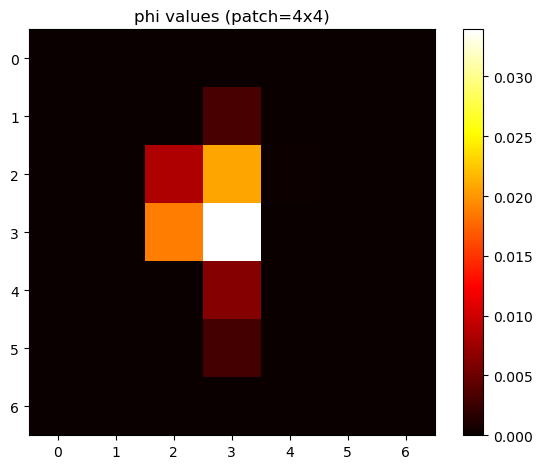

In [80]:
fig = plot_minshap_result(result, X_example=X_test[0], y_example=y_test[0])
plt.show()
fig.savefig("minshap_4")